# Geometric Brownian motion

Geometric Brownian motion (GBM) is the standard model for strictly positive, compounding quantities — asset prices, populations, anything that grows *multiplicatively*. Its log grows as a drifting random walk, so the level is log-normal and never goes negative.

::: {.callout-note}
## The model

$$dS_t = \mu\,S_t\,dt + \sigma\,S_t\,dW_t$$

Returns are proportional to the current level: `drift` (`mu`) sets the exponential growth rate and `volatility` (`sigma`) the multiplicative noise. This is the process behind Black-Scholes option pricing.
:::

In [ ]:
import polars as pl
import matplotlib.pyplot as plt

from synforecast.generators import GeometricBrownianMotionGenerator

## 1. Drift

`drift` is the exponential growth rate. The seed is shared, so the three paths have identical noise and differ only in trend direction.


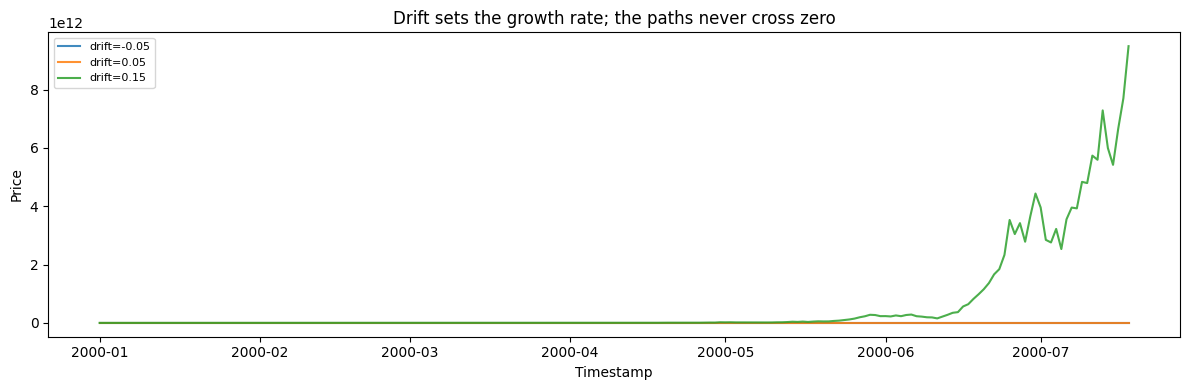

In [ ]:
base = {
    "min_length": 200,
    "max_length": 200,
    "freq": "D",
    "sigma": 0.2,
    "initial_value": 100.0,
    "seed": 42,
}

fig, ax = plt.subplots(figsize=(12, 4))
for mu in (-0.05, 0.05, 0.15):
    df = GeometricBrownianMotionGenerator(
        engine="polars", mu=mu, **base
    ).generate(n_series=1)
    ax.plot(df["ds"].to_list(), df["y"].to_list(), label=f"drift={mu}", alpha=0.85)
ax.set(
    xlabel="Timestamp",
    ylabel="Price",
    title="Drift sets the growth rate; the paths never cross zero",
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 2. Volatility

`volatility` scales the multiplicative noise. Because the process is multiplicative, the spread grows with the level rather than staying constant.


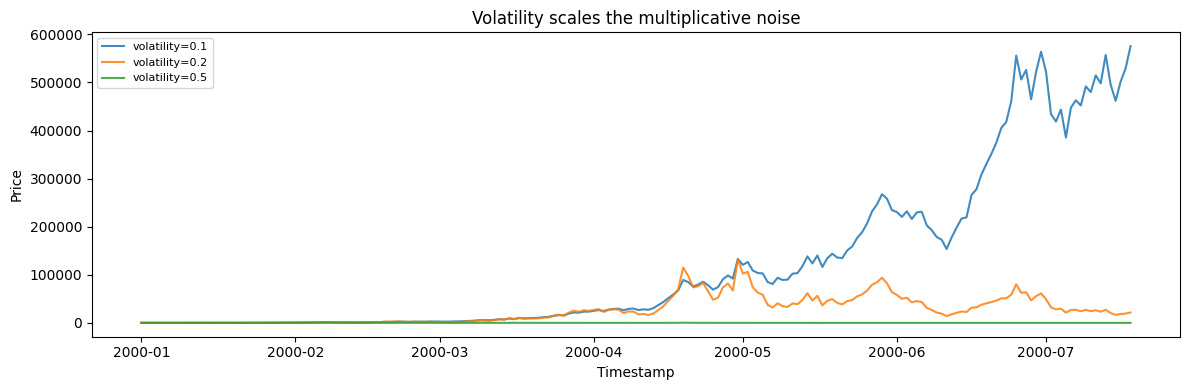

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for sigma in (0.1, 0.2, 0.5):
    df = GeometricBrownianMotionGenerator(
        engine="polars",
        min_length=200,
        max_length=200,
        freq="D",
        mu=0.05,
        sigma=sigma,
        initial_value=100.0,
        seed=42,
    ).generate(n_series=1)
    ax.plot(df["ds"].to_list(), df["y"].to_list(), label=f"volatility={sigma}", alpha=0.85)
ax.set(
    xlabel="Timestamp",
    ylabel="Price",
    title="Volatility scales the multiplicative noise",
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 3. Multiple paths

Generate 5 independent GBM paths in one call.

In [ ]:
multi_params = {
    "min_length": 150,
    "max_length": 150,
    "freq": "D",
    "mu": 0.05,
    "sigma": 0.2,
    "initial_value": 100.0,
    "seed": 42,
}

multi_gen = GeometricBrownianMotionGenerator(engine="polars", **multi_params)
multi_df = multi_gen.generate(n_series=5)

print(f"Generated 5 stock price simulations with {len(multi_df)} total observations")
print(f"Overall Statistics: Mean={multi_df['y'].mean():.4f}, Min={multi_df['y'].min():.4f}, Max={multi_df['y'].max():.4f}")
multi_df.filter(pl.col("unique_id") == "0").head(10)

Generated 5 stock price simulations with 750 total observations
Overall Statistics: Mean=33529.5984, Min=39.7278, Max=1355600.3980


unique_id,ds,y
cat,datetime[ns],f64
"""0""",2000-01-01 00:00:00,100.0
"""0""",2000-01-02 00:00:00,77.855257
"""0""",2000-01-03 00:00:00,66.931005
"""0""",2000-01-04 00:00:00,83.485543
"""0""",2000-01-05 00:00:00,92.09352
"""0""",2000-01-06 00:00:00,85.875252
"""0""",2000-01-07 00:00:00,77.473016
"""0""",2000-01-08 00:00:00,90.038957
"""0""",2000-01-09 00:00:00,86.666449


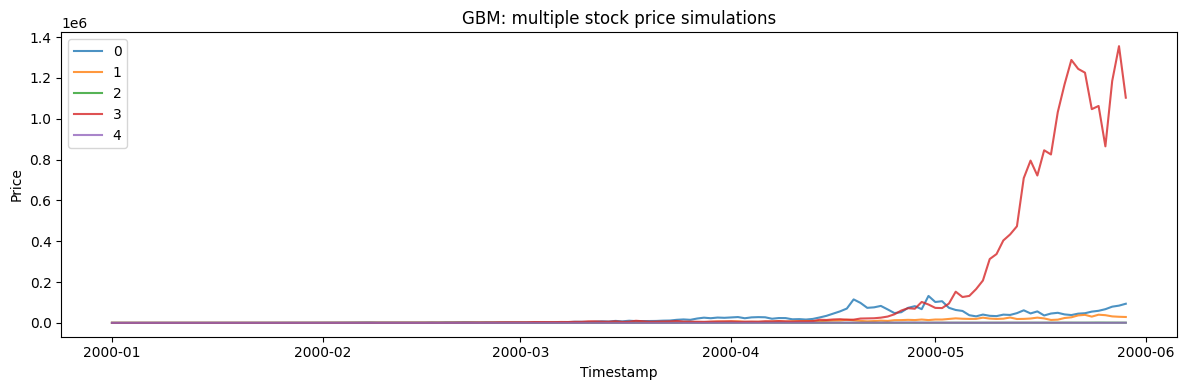

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for uid in multi_df["unique_id"].unique().to_list():
    series = multi_df.filter(pl.col("unique_id") == uid)
    ax.plot(series["ds"].to_list(), series["y"].to_list(), label=uid, alpha=0.8)
ax.set_xlabel("Timestamp")
ax.set_ylabel("Price")
ax.set_title("GBM: multiple stock price simulations")
ax.legend()
plt.tight_layout()
plt.show()

::: {.callout-tip}
## Related generators

- [Random walk](/synforecast/docs/generators/statistical/random_walk.html) — the *additive* counterpart.
- [Jump diffusion](/synforecast/docs/generators/stochastic/jump_diffusion.html) — GBM plus sudden jumps.

Drift and volatility parameters are in the [generator reference](https://github.com/Nixtla/synforecast/blob/main/GENERATORS.md).
:::